# Exploration 3: copy number

Description of the copy-number ground truth and of its reconstruction uncertainty (entropy), calibration (ECE),
log score and balanced accuracy, in-sample (IS) vs out-of-sample (OOD). Reads the files written by
`metrics_2_copynumber`; the calibration diagrams also load the aligned data and samples (read-only).

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import pearsonr, spearmanr

import omics_config as cfg
import omics_metrics as om
import omics_plots as op

METHOD = "latent"          # "latent" | "mcd"
EXAMPLE_FEATURE = "ABCB1"  # feature used for the single-feature plots

OMIC = "copynumber"
m = op.load_metrics(METHOD, omics=[OMIC])
info = op.load_raw_feature_info(omics=[OMIC])
truth = om.load_ground_truth(OMIC)                                     # all samples, with missing values
prepared = {}                                                          # (data, imputed, cube) per setting
for s in cfg.SETTINGS:
    prepared[s] = om.load_prepared(OMIC, METHOD, s)
sharp = {s: m[OMIC][s]["sharpness"] for s in m[OMIC]}  # settings available for METHOD

Skipped copynumber latent OOD: not evaluated (cfg.UNAVAILABLE)


## 1. The ground truth

In [2]:
class_stats = op.cn_dataset_description(truth, imputed=om.load_imputed(OMIC, "IS"))

The dataset has 2.55% missing values
Features with missing values: 59
  mean 33.63%, max 89.63% ['FAM186A', 'FOXD4L1', 'HOXA13', 'LY75-CD302', 'MLLT11', 'NUTM2B', 'NUTM2D', 'RGPD3', 'SETD1B', 'SSX2', 'TRIM49C', 'U2AF1', 'ZNF721', 'ZNF814'], min 0.07% ['CYSLTR2']

Total features: 777
Unique values per feature: mean 4.33, median 4.0, min 3, max 5
Number of features by number of unique values:
3     14
4    494
5    269

Most frequent values across all features (%):
 0.0    72.90
-1.0    13.60
 1.0    11.34
 2.0     1.80
-2.0     0.36

Features whose predicted values cover exactly the observed classes: 169 of 777
  e.g. ABCB1: data {0, 1, 2, -1} vs imputed {0.0, 1.0, 2.0, -2.0, -1.0}
  e.g. ABI1: data {0, 1, 2, -1} vs imputed {-0.0, 1.0, 2.0, 3.0, -2.0, -1.0}
  e.g. ABL1: data {0, 1, 2, -1} vs imputed {-0.0, 1.0, 2.0, -2.0, -1.0}



Features with only 2 classes: 0
High-diversity features (entropy > 0.1 bits and >= 3 classes with p > 0.05): 637 of 777

Example class distribution for 'ABCB1':
 class      p_i
    -2 0.000000
    -1 0.057225
     0 0.658798
     1 0.247496
     2 0.036481


## 2. Entropy of the sampled classes (sharpness)
0 = all samples agree; 1 = uniform over the five classes.

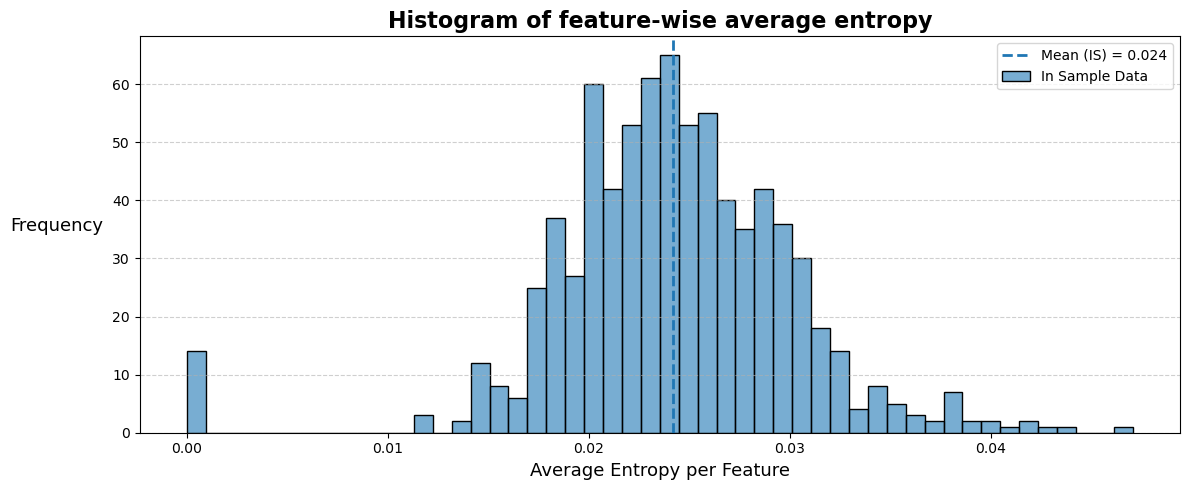

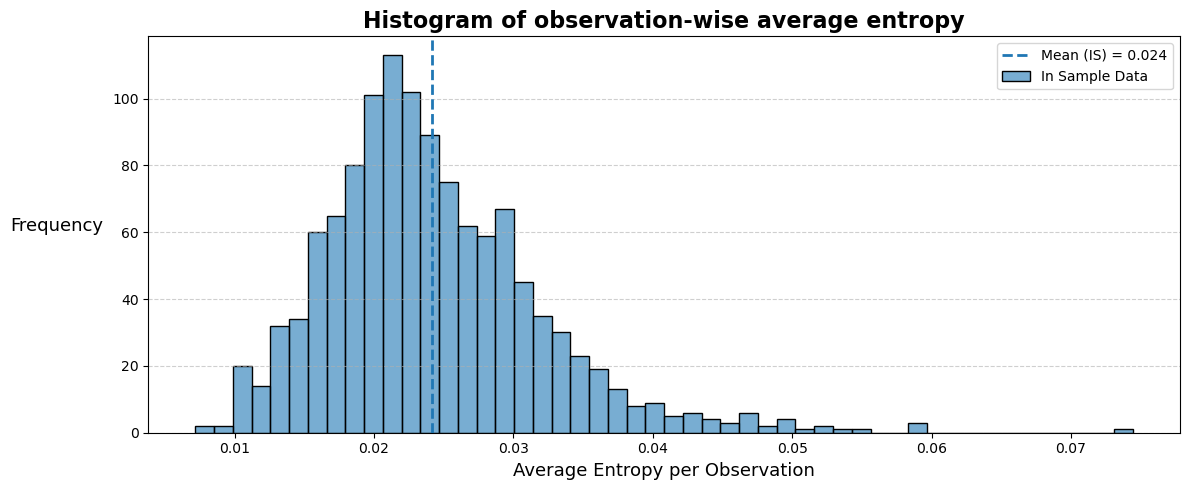

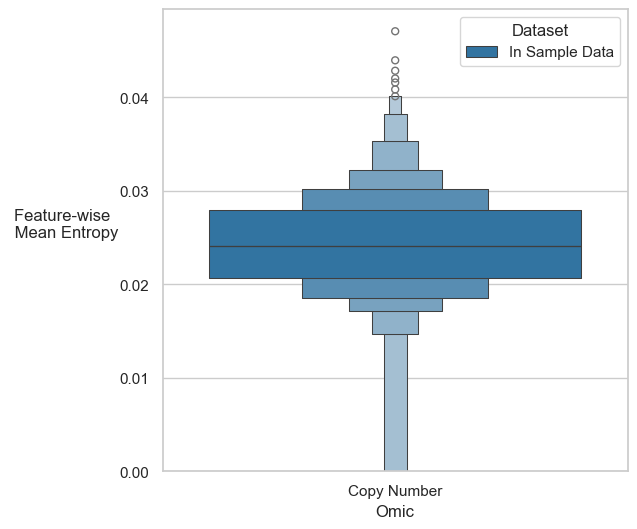

In [3]:
op.plot_entropy_hist_is_ood(sharp, axis=0)
op.plot_entropy_hist_is_ood(sharp, axis=1)
op.plot_distribution(m, "sharpness", omics=[OMIC], ylabel="Feature-wise \n Mean Entropy")

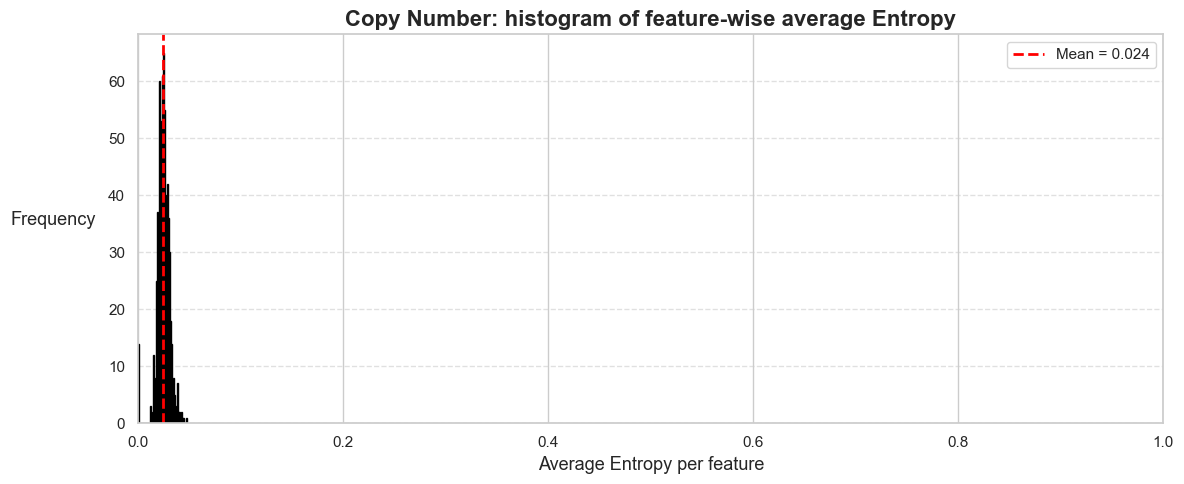

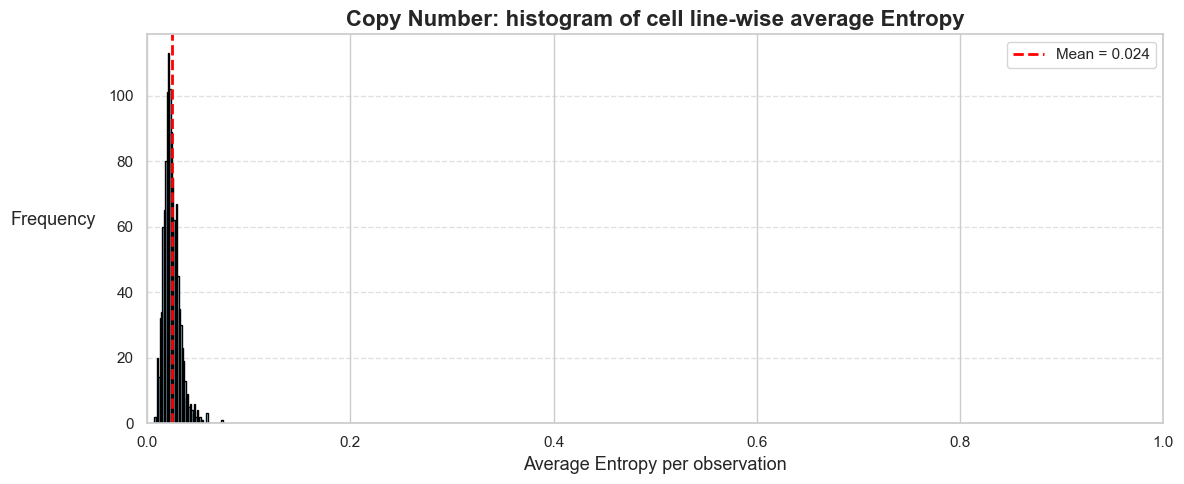

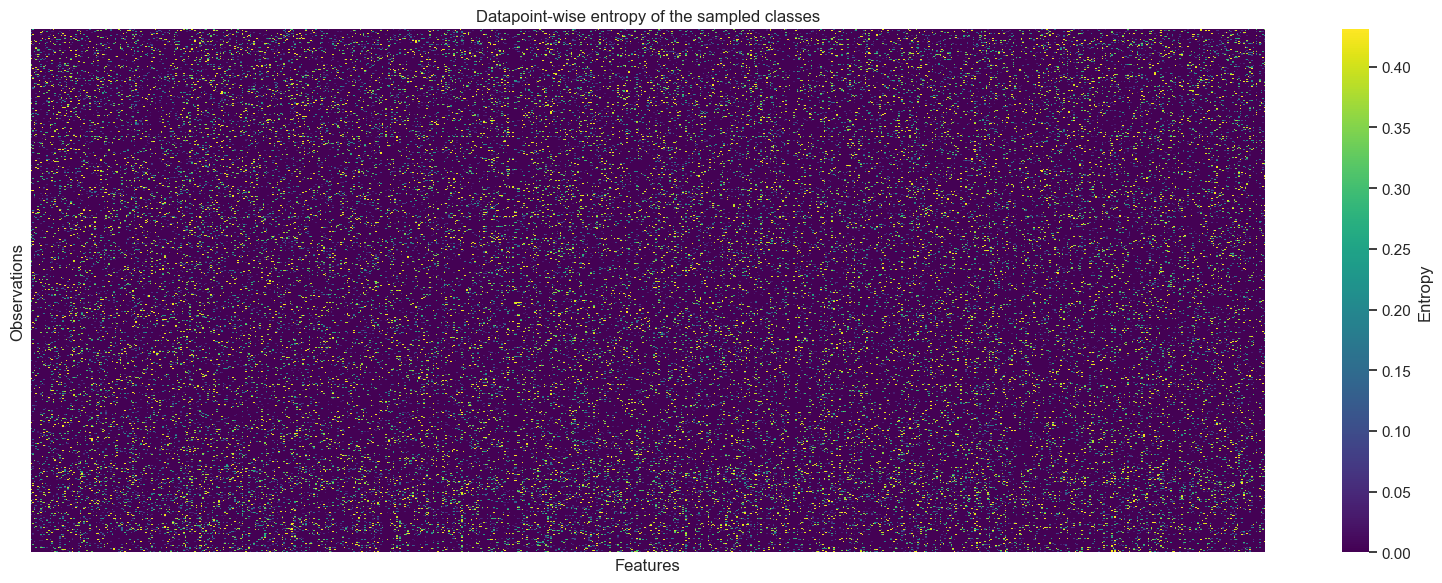

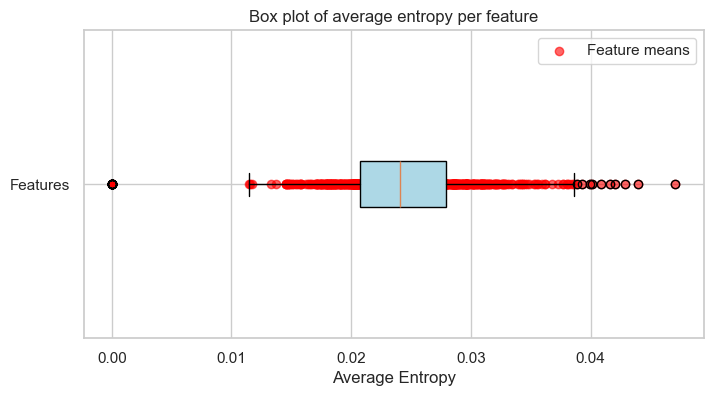

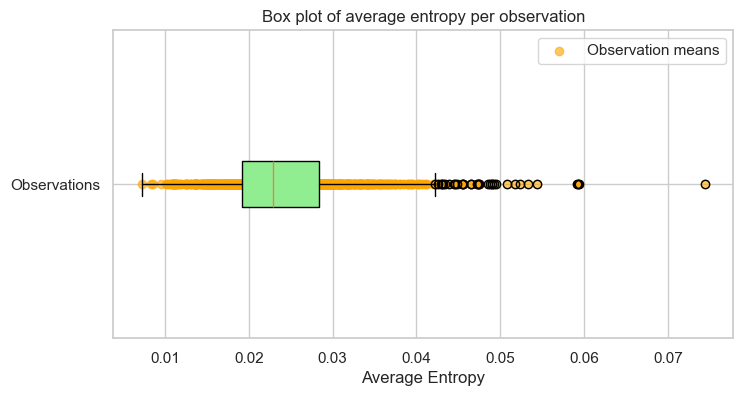

Outlier features (by average entropy): 24 / 777 (3.09%)
['ZNF814', 'FAM186A', 'FOXD4L1', 'U2AF1', 'HOXA13', 'LY75-CD302', 'MLLT11', 'TRIM49C', 'SSX2', 'SETD1B', 'ZNF721', 'NUTM2B', 'NUTM2D', 'RGPD3', 'MGA', 'NPEPPS', 'NF1', 'PDCD1LG2', 'COL2A1', 'GMPS', 'MTCP1', 'TCEA1', 'MLLT3', 'RSPH10B2']
Outlier observations (by average entropy): 34 / 1198 (2.84%)
['SIDM01658', 'SIDM00100', 'SIDM01782', 'SIDM00154', 'SIDM00113', 'SIDM01368', 'SIDM00234', 'SIDM00077', 'SIDM01679', 'SIDM01780', 'SIDM00584', 'SIDM01774', 'SIDM01764', 'SIDM00075', 'SIDM00310', 'SIDM01460', 'SIDM01335', 'SIDM00063', 'SIDM00784', 'SIDM01490', 'SIDM01483', 'SIDM00104', 'SIDM00171', 'SIDM00991', 'SIDM01320', 'SIDM01605', 'SIDM00518', 'SIDM01560', 'SIDM00103', 'SIDM00400', 'SIDM00357', 'SIDM00057', 'SIDM01596', 'SIDM00311']



Outlier datapoints: 102511 / 930846 (11.01%)
SIDM00517  CHCHD7     0.034796
SIDM00388  FAS        0.034796
SIDM01522  SUZ12      0.034796
SIDM00388  ERCC4      0.034796
           EPS15      0.034796
SIDM01522  TCEA1      0.034796
SIDM00388  CPEB3      0.034796
           CDKN2A     0.034796
           CDC73      0.034796
           BRCA1      0.034796
SIDM01114  ALB        0.034796
SIDM00388  AKT2       0.034796
           ABCB1      0.034796
SIDM00387  UGT2B17    0.034796
SIDM01522  VHL        0.034796
SIDM00387  TRAF7      0.034796
SIDM01113  TET1       0.034796
SIDM00387  SUZ12      0.034796
SIDM00976  TPM3       0.034796
SIDM00387  ROS1       0.034796
0.0% of the features have a mean entropy above 0.5


In [4]:
op.plot_mean_histograms(sharp["IS"], OMIC, what="Entropy", xlim=(0, 1))
op.plot_entropy_overview(sharp["IS"])
op.entropy_outlier_report(sharp["IS"])
feature_means = sharp["IS"].mean()
print(f"{100 * (feature_means > 0.5).mean():.1f}% of the features have a mean entropy above 0.5")

## 3. Entropy by ground-truth class

In Sample Data


,Class,Mean Sharpness,Std Sharpness,n_datapoints,percent_datapoints
0,-2,0.014915,0.065226,3763,0.404256
1,-1,0.023602,0.082095,125525,13.485045
2,0,0.025335,0.084872,651219,69.959907
3,1,0.022645,0.080834,107551,11.554113
4,2,0.015972,0.068436,16519,1.774622
5,N/a,0.011364,0.057944,26269,2.822056


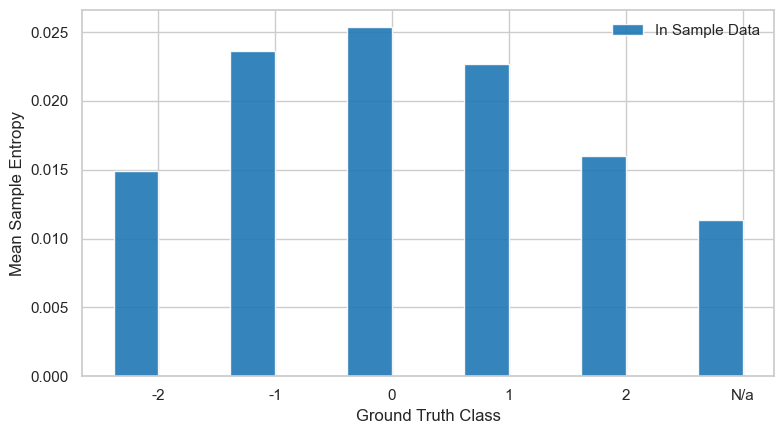

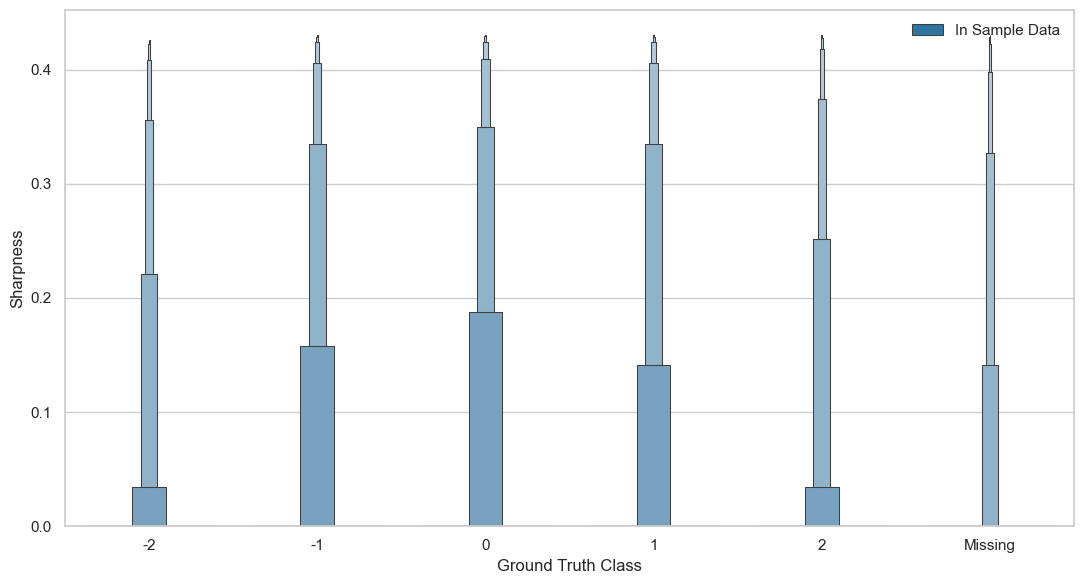

In [5]:
class_tables = {s: op.class_sharpness_table(truth, sharp[s]) for s in sharp}
for s, table in class_tables.items():
    print(op.SETTING_LABELS[s])
    display(table)
op.plot_class_sharpness_bars(class_tables)
op.plot_class_sharpness_boxen(truth, sharp)

## 4. Calibration (ECE)
Reliability diagrams use exactly the confidence, binning and ground-truth mask of the saved ECE.

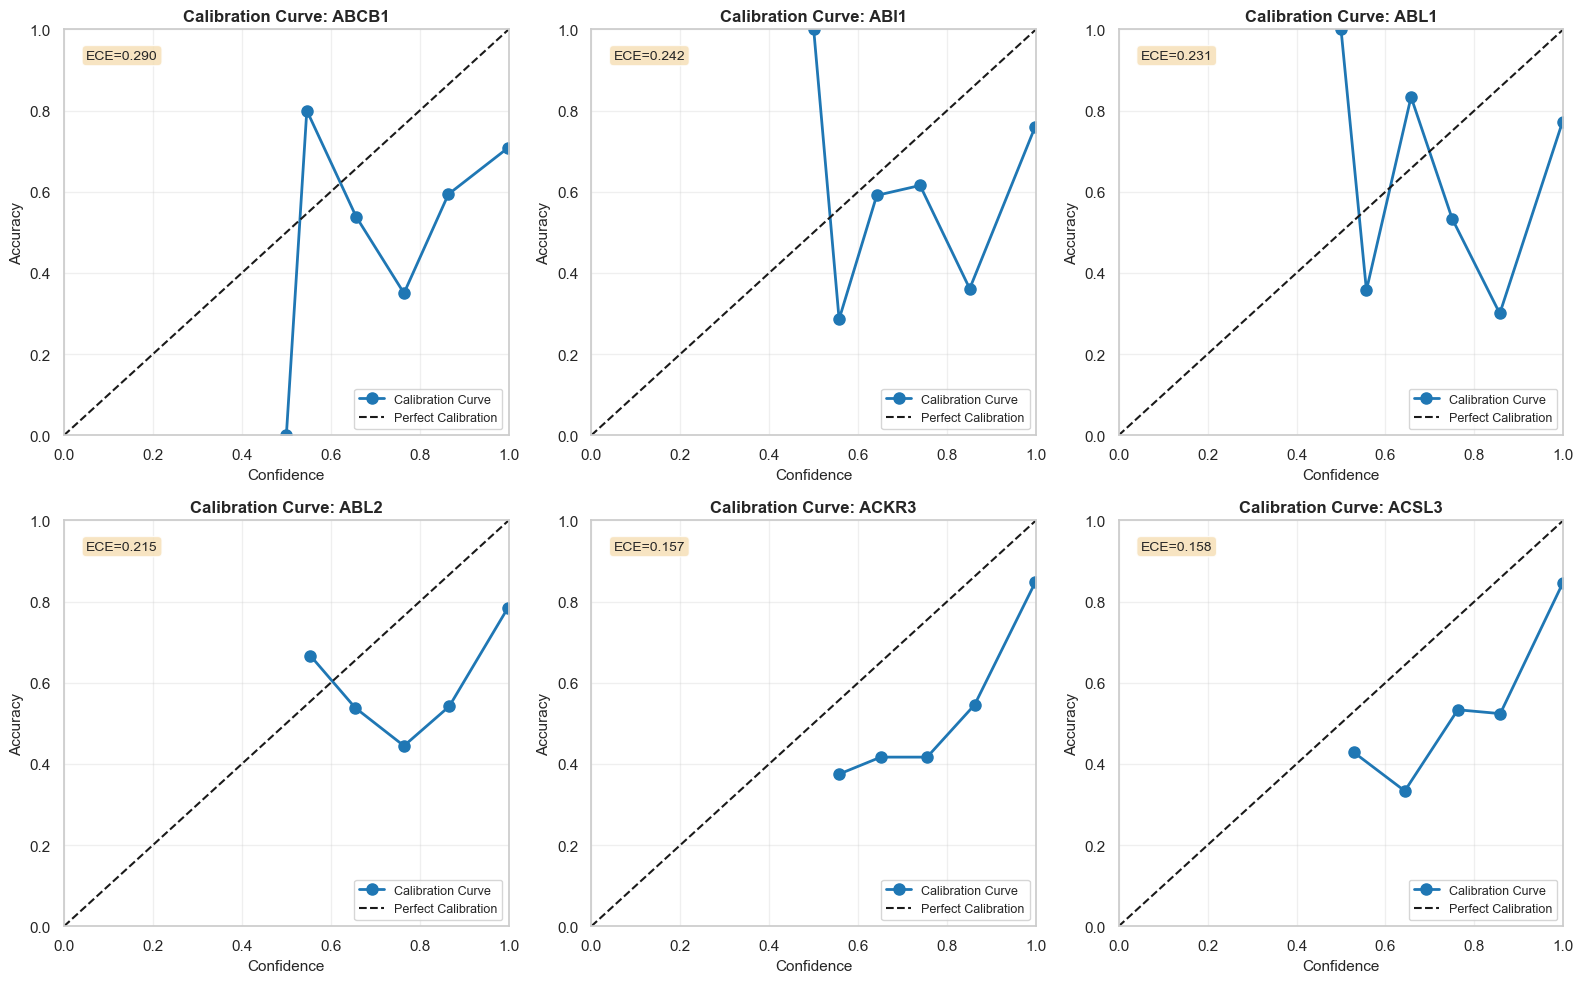

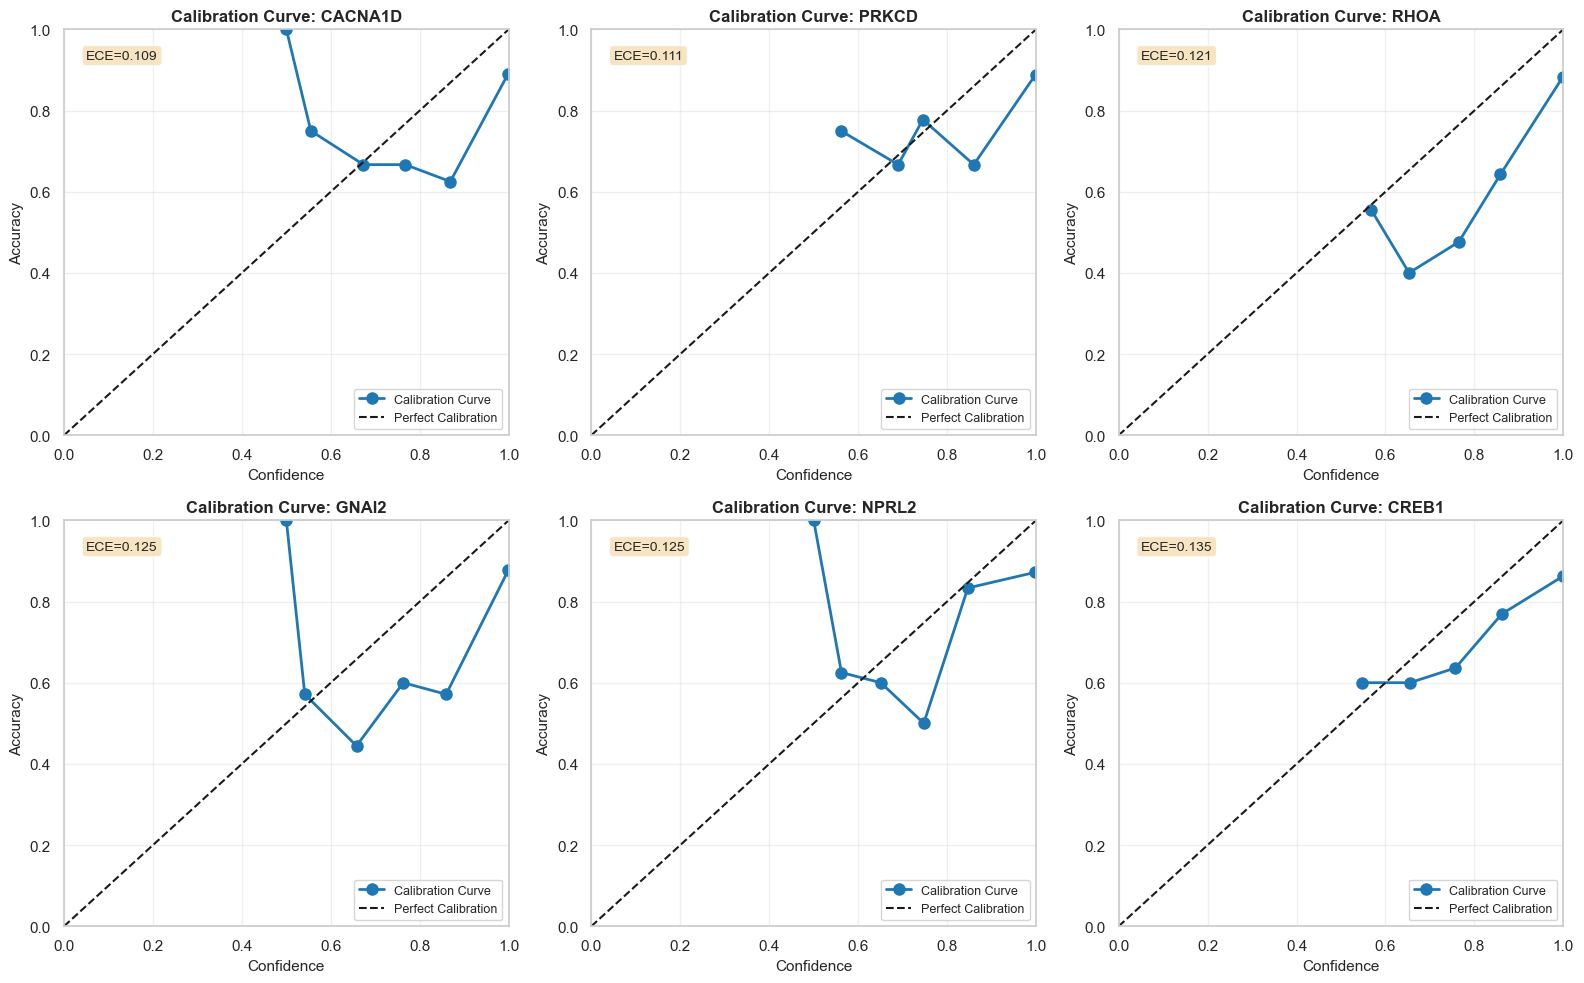

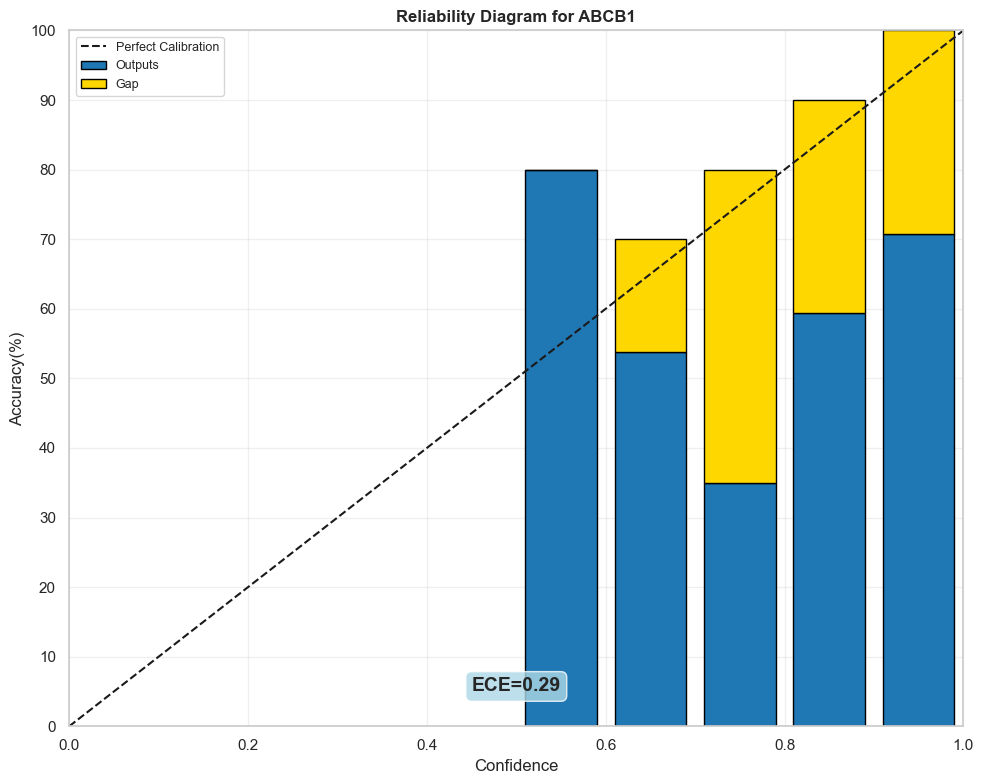

    Bin  Count  Mean Confidence  Accuracy
0.4-0.5      1            0.500     0.000
0.5-0.6     10            0.546     0.800
0.6-0.7     13            0.657     0.538
0.7-0.8     20            0.765     0.350
0.8-0.9     32            0.864     0.594
0.9-1.0   1122            0.998     0.708


In [6]:
data, imputed, cube = prepared["IS"]
ece = m[OMIC]["IS"]["calibration"]
op.cn_reliability(data, cube, data.columns[:6])
op.cn_reliability(data, cube, ece.nsmallest(6).index)
op.cn_reliability(data, cube, [EXAMPLE_FEATURE], style="gap_bars", min_obs=10)

Pooled over all features.

In Sample Data


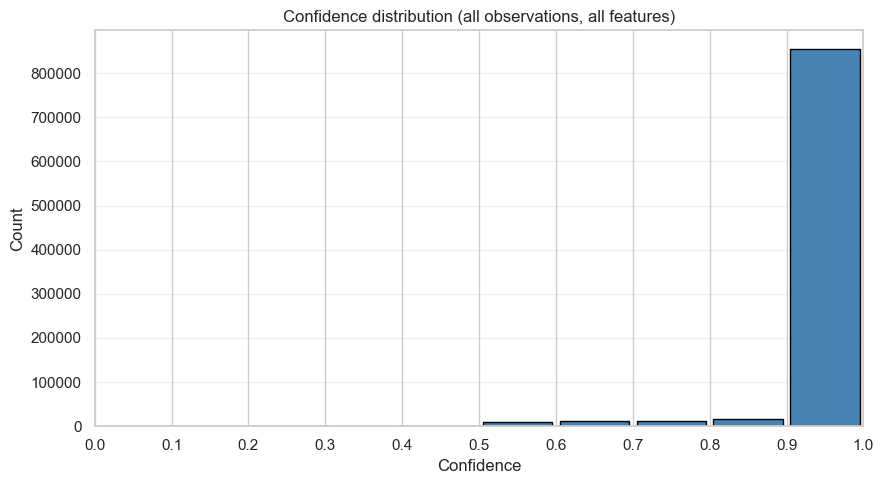

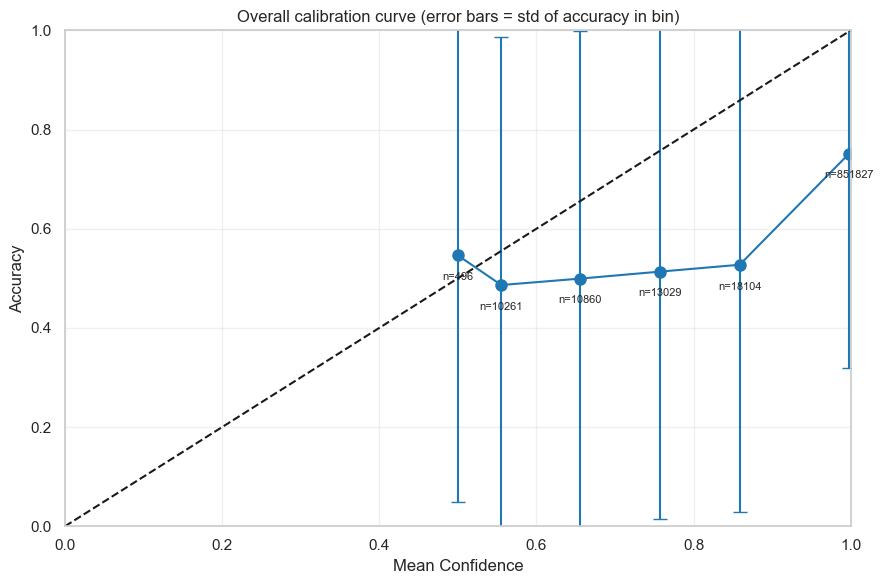

,bin,count,mean_confidence,mean_accuracy,std_accuracy
0,0.00-0.10,0,NaN,NaN,NaN
1,0.10-0.20,0,NaN,NaN,NaN
2,0.20-0.30,0,NaN,NaN,NaN
3,0.30-0.40,0,NaN,NaN,NaN
4,0.40-0.50,496,0.5000,0.5464,0.4978
5,0.50-0.60,10261,0.5553,0.4865,0.4998
6,0.60-0.70,10860,0.6558,0.4994,0.5000
7,0.70-0.80,13029,0.7568,0.5135,0.4998
8,0.80-0.90,18104,0.8588,0.5274,0.4992
9,0.90-1.00,851827,0.9980,0.7516,0.4321


In [7]:
for s, (data_s, _, cube_s) in prepared.items():
    print(op.SETTING_LABELS[s])
    display(op.cn_overall_calibration(data_s, cube_s))

## 5. Log score

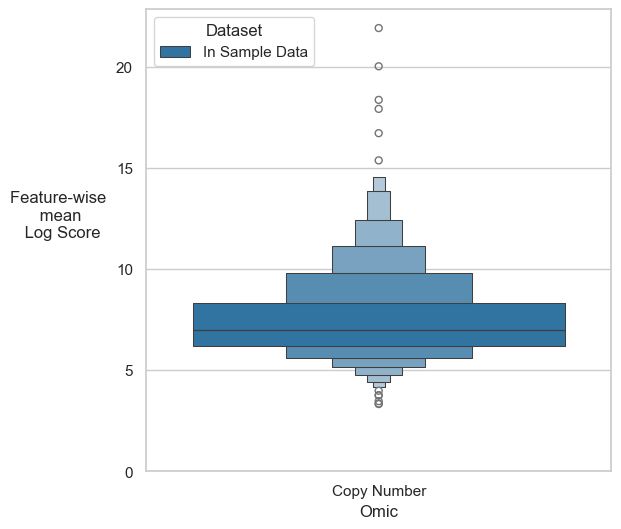

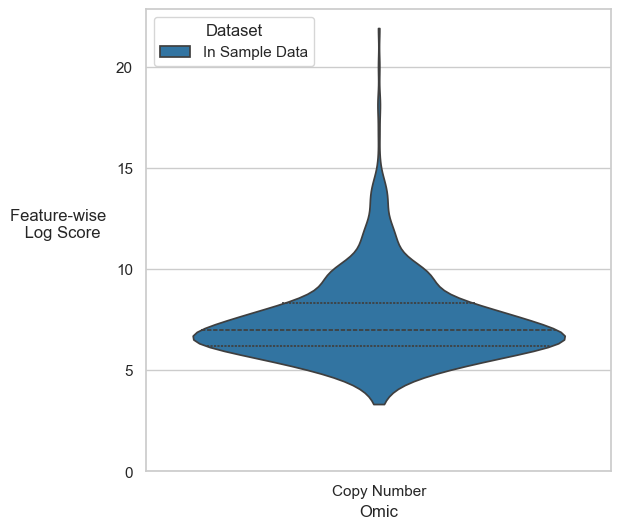

In [8]:
op.plot_distribution(m, "scoring", omics=[OMIC], ylabel="Feature-wise \n mean \n Log Score", legend_loc="upper left")
op.plot_distribution(m, "scoring", omics=[OMIC], kind="violin", ylabel="Feature-wise \n Log Score", legend_loc="upper left")

count    1.198000e+03
mean     8.640185e+00
std      1.479128e+01
min      3.996803e-15
25%      4.218847e-15
50%      4.218847e-15
75%      4.605170e+00
max      3.453878e+01
Name: ABCB1, dtype: float64

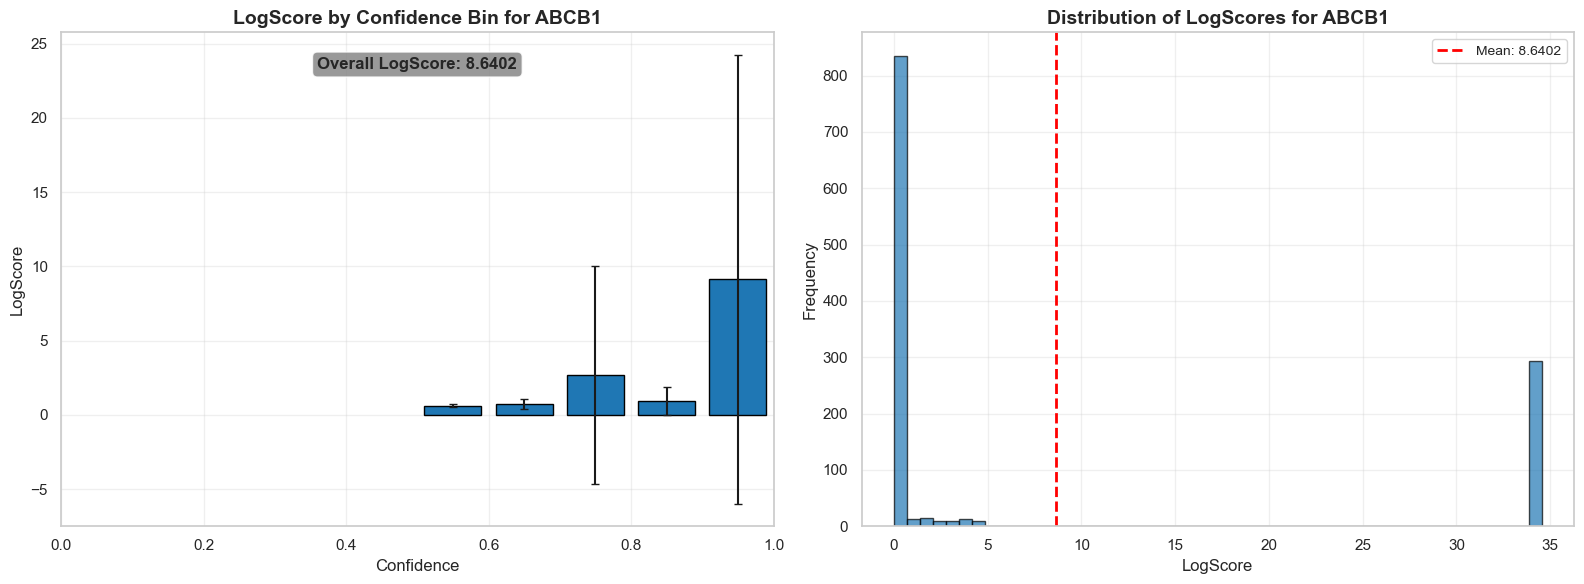

,Bin,Count,Mean Conf,Mean LogScore,Std LogScore
0,0.5-0.6,10,0.546000,0.637940,0.079450
1,0.6-0.7,13,0.656923,0.734856,0.335050
2,0.7-0.8,20,0.764500,2.683987,7.329442
3,0.8-0.9,32,0.864375,0.916899,0.939477
4,0.9-1.0,1122,0.998021,9.136627,15.115921


In [9]:
logscores = pd.read_csv(cfg.output_path("logscore", OMIC, METHOD, "IS"), index_col=0)
display(logscores[EXAMPLE_FEATURE].describe())
display(op.cn_logscore_by_confidence(data, cube, logscores, EXAMPLE_FEATURE))

## 6. Balanced accuracy vs calibration
Each point is a feature, coloured by the diversity of its ground-truth classes.

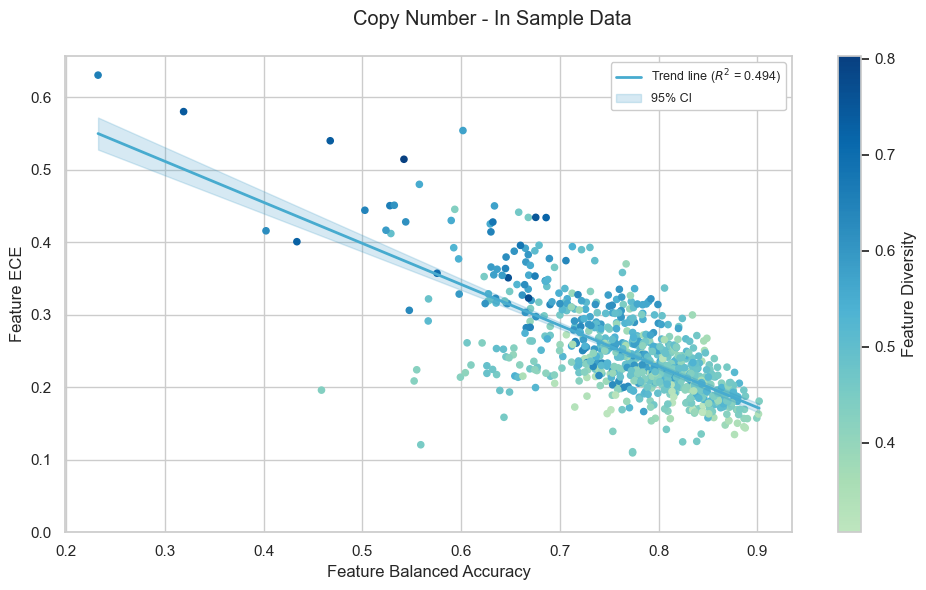

In [10]:
op.compare_is_ood(m, OMIC, x="error", y="calibration", c="diversity", info=info)